In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoProcessor, AutoModel

class TextEncoder(nn.Module):
    def __init__(self, device, d_model):
        super().__init__()

        self.d_model = d_model
        self.device = device

        self.tokenizer = AutoTokenizer.from_pretrained("jinaai/jina-clip-v2", trust_remote_code=True, dtype="auto")
        self.processor = AutoProcessor.from_pretrained("jinaai/jina-clip-v2", trust_remote_code=True, dtype="auto")
        self.model = AutoModel.from_pretrained("jinaai/jina-clip-v2", trust_remote_code=True, dtype="auto").to(device)

        num_paramters = sum([param.numel() for param in self.parameters()])

        print("num_paramters: ", num_paramters)
        for param in self.parameters():
            param.requires_grad = False

    @torch.no_grad()
    def forward(self, texts: list[str]):
        safe_texts = [text if (text and text.strip() != "") else " " for text in texts]
        
        tokenized_text = self.tokenizer(safe_texts, padding=True, return_tensors="pt")
        tokenized_text = {key: value.to(self.device) for key, value in tokenized_text.items()}

        embedding_matrix = self.model.get_text_features(**tokenized_text).normalize
        return F.normalize(embedding_matrix, dim=1)

/media/bahgat/bahgat/DEPI Data Science/Deep Learning/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class IDEncoder(nn.Module):
    def __init__(self, device, d_model, num_users, num_tweets, num_authors):
        super().__init__()

        self.device = device
        self.d_model = d_model

        self.user_embeddings = nn.Embedding(num_embeddings=num_users, embedding_dim=d_model)
        self.tweet_embeddings = nn.Embedding(num_embeddings=num_tweets, embedding_dim=d_model)
        self.author_embeddings = nn.Embedding(num_embeddings=num_authors, embedding_dim=d_model)
    
    def forward(self, userId, tweetId, authorId):
        result = []
        if userId:
            result.append(self.user_embeddings(userId))
        if tweetId:
            result.append(self.tweet_embeddings(tweetId))
        if authorId:
            result.append(self.author_embeddings(authorId))
        return result

In [3]:
class CIN(nn.Module):
    def __init__(self, m, d_model, layer_sizes):
        """
        m: number of fields (H_0)
        d_model: embedding dimension
        layer_sizes: list containing the number of feature maps H_k per layer
        """
        super().__init__()
        self.m = m
        self.d_model = d_model
        self.layer_sizes = layer_sizes
        self.filters = nn.ParameterList()
        
        # Initialize the filters (W) for each layer
        prev_H = m
        for H_k in layer_sizes:
            # The filter W shape is (H_k, H_{k-1}, m)
            # H_k = number of feature maps we want to output
            # prev_H = number of feature maps from previous layer
            # m = number of original fields
            # torch.Tensor for manula initialization
            W = nn.Parameter(torch.Tensor(H_k, prev_H, m))
            nn.init.kaiming_normal_(W)
            self.filters.append(W)
            prev_H = H_k

    def forward(self, X_0):
        """
        X_0 shape: (batch_size, m, d_model)
        """
        X_k = X_0
        hidden_layers = []
        
        for W in self.filters:
            # We use einsum to simultaneously calculate the Z tensor AND apply the filters.
            # b = batch_size
            # h = H_{k-1} (feature maps from previous layer)
            # m = fields from X_0
            # d = embedding dimension (D)
            # f = H_k (number of new feature maps)
            
            # X_k shape: (b, h, d)
            # X_0 shape: (b, m, d)
            # W shape:   (f, h, m)
            # Output shape: (b, f, d)
            
            # The einsum formula translates directly to Eq 6:
            # We multiply W * X_k * X_0 and sum over 'h' and 'm'.
            X_k = torch.einsum('fhm,bhd,bmd->bfd', W, X_k, X_0)
            
            hidden_layers.append(X_k)
            
        # As per Section 3.1, apply sum pooling on each feature map [cite: 238]
        # p_i^k = sum(X_{i,j}^k) for j=1 to D [cite: 239]
        pooled_layers = [torch.sum(layer, dim=-1) for layer in hidden_layers]
        
        # All pooling vectors are concatenated [cite: 242]
        # Shape: (batch_size, sum(layer_sizes))
        p_plus = torch.cat(pooled_layers, dim=-1) 
        
        return p_plus

In [4]:
class xDeepFM(nn.Module):
    def __init__(self, device, d_model, d_clip, num_users, num_tweets, num_authors):
        super().__init__()

        self.device = device
        self.d_model = d_model
        layer_sizes = [100, 100, 100]

        self.userIds = nn.Embedding(num_embeddings=num_users, embedding_dim=d_model)
        self.tweetIds = nn.Embedding(num_embeddings=num_tweets, embedding_dim=d_model)
        self.authorIds = nn.Embedding(num_embeddings=num_authors, embedding_dim=d_model)

        self.linear = nn.Linear(self.d_model * 4, 1)

        self.condense_dense_embeddings = nn.Sequential(
            nn.Linear(d_clip, d_model),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(d_model, d_model),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(d_model, d_model),
        )

        self.dnn = nn.Sequential(
            nn.Linear(self.d_model * 4, d_model * 2),
            nn.BatchNorm1d(d_model * 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(d_model * 2, d_model),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(d_model, d_model),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(d_model, d_model), #(B, D, D)
        )

        self.cin = CIN(m=4, d_model=d_model, layer_sizes=layer_sizes)

        self.output_unit = nn.Linear(d_model + sum(layer_sizes) + 1, 1)

        num_parameters = sum([param.numel() for param in self.parameters()])
        print("xDeepFM parameters: ", num_parameters)
    
    def forward(self, user_id, tweet_id, author_id, clip_tensor) -> torch.Tensor:
        e_u = self.userIds(user_id)
        e_t = self.tweetIds(tweet_id)
        e_a = self.authorIds(author_id)
        e_c = self.condense_dense_embeddings(clip_tensor)

        cin_input_tensor = torch.stack([e_u, e_t, e_a, e_c], dim=1)
        _input_tensor = torch.cat([e_u, e_t, e_a, e_c], dim=-1)

        linear_result = self.linear(_input_tensor.detach())     # Shape: (B, 1)
        deep_result = self.dnn(_input_tensor)          # Shape: (B, d_model)
        cin_result = self.cin(cin_input_tensor)        # Shape: (B, sum(layer_sizes))

        # 4. Final Combination
        # Concatenate the outputs of the three branches together
        combined_features = torch.cat([linear_result, cin_result, deep_result], dim=-1)

        logits = self.output_unit(combined_features)

        return logits

In [5]:
from torch.optim import Optimizer

class FTRL(Optimizer):
    def __init__(self, params, alpha=0.01, beta=1.0, l1=0.0, l2=0.0):
        """
        FTRL (Follow-The-Regularized-Leader) Optimizer.
        alpha: Learning rate
        beta: Smoothing parameter
        l1: L1 regularization strength (drives sparsity)
        l2: L2 regularization strength
        """
        if alpha <= 0.0:
            raise ValueError(f"Invalid alpha value: {alpha}")
        
        defaults = dict(alpha=alpha, beta=beta, l1=l1, l2=l2)
        super(FTRL, self).__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                    
                grad = p.grad
                state = self.state[p]

                # State initialization
                if len(state) == 0:
                    state['z'] = torch.zeros_like(p.data)
                    state['n'] = torch.zeros_like(p.data)

                z, n = state['z'], state['n']
                alpha, beta, l1, l2 = group['alpha'], group['beta'], group['l1'], group['l2']

                # Update n and sigma
                # sigma = (sqrt(n_new) - sqrt(n_old)) / alpha
                sigma = (torch.sqrt(n + grad ** 2) - torch.sqrt(n)) / alpha
                
                # z += grad - sigma * w
                z.add_(grad - sigma * p.data)
                
                # n += grad^2
                n.add_(grad ** 2)

                # Update weights (p.data)
                z_val = z.clone()
                
                # Apply L1 regularization mask
                mask = z_val.abs() > l1
                
                w = torch.zeros_like(p.data)
                # w = -(z - sign(z)*l1) / ((beta + sqrt(n))/alpha + l2)
                w[mask] = - (z_val[mask] - z_val[mask].sign() * l1) / ((beta + torch.sqrt(n[mask])) / alpha + l2)
                
                p.data.copy_(w)

        return loss

In [6]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc, 
    confusion_matrix, precision_score, recall_score, f1_score, average_precision_score
)
import copy

class RecDataset(Dataset):
    def __init__(self, df, dense_embeddings_path):
        """
        df: Pandas DataFrame containing user_id, tweet_id, author_id, label, and npy_index.
            'npy_index' should be the row index corresponding to this sample in the .npy file.
        """
        self.df = df.reset_index(drop=True)
        # Load mmap_mode="r" to keep memory footprint low
        self.dense_embeddings = np.load(dense_embeddings_path, mmap_mode="r")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        user_id = torch.tensor(int(row['userId']), dtype=torch.long)
        tweet_id = torch.tensor(int(row['tweetId']), dtype=torch.long)
        author_id = torch.tensor(int(row['authorId']), dtype=torch.long)
        label = torch.tensor(float(row['target']), dtype=torch.float32)
        
        # Fetch the pre-computed embedding
        clip_idx = int(row['npy_index'])
        clip_tensor = torch.tensor(self.dense_embeddings[clip_idx], dtype=torch.float32)
        
        return user_id, tweet_id, author_id, clip_tensor, label

In [7]:
def train_epoch(model, dataloader, criterion, optimizer_adam, optimizer_ftrl, device):
    model.train()
    total_loss = 0.0
    
    pbar = tqdm(dataloader, desc="Training", leave=False)
    for user_id, tweet_id, author_id, clip_tensor, labels in pbar:
        user_id, tweet_id, author_id = user_id.to(device), tweet_id.to(device), author_id.to(device)
        clip_tensor, labels = clip_tensor.to(device), labels.to(device)
        
        # Zero gradients for both optimizers
        optimizer_adam.zero_grad()
        optimizer_ftrl.zero_grad()
        
        # Forward pass
        logits = model(user_id, tweet_id, author_id, clip_tensor).squeeze(-1)
        loss = criterion(logits, labels)
        
        # Backward pass
        loss.backward()
        
        # Step both optimizers
        optimizer_ftrl.step()
        optimizer_adam.step()
        
        total_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        
    return total_loss / len(dataloader)

@torch.no_grad()
def evaluate_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_targets = []
    all_preds = []
    
    pbar = tqdm(dataloader, desc="Evaluating", leave=False)
    for user_id, tweet_id, author_id, clip_tensor, labels in pbar:
        user_id, tweet_id, author_id = user_id.to(device), tweet_id.to(device), author_id.to(device)
        clip_tensor, labels = clip_tensor.to(device), labels.to(device)
        
        logits = model(user_id, tweet_id, author_id, clip_tensor).squeeze(-1)
        loss = criterion(logits, labels)
        
        total_loss += loss.item()
        
        # Apply sigmoid to get probabilities for metrics
        probs = torch.sigmoid(logits)
        
        all_targets.extend(labels.cpu().numpy())
        all_preds.extend(probs.cpu().numpy())
        
    return total_loss / len(dataloader), np.array(all_targets), np.array(all_preds)

In [8]:
def train_and_test(model, train_loader, val_loader, test_loader, device, epochs=20, patience=5):
    # Calculate pos_weight dynamically from the training loader
    # (Assuming label 1 is positive and 0 is negative)
    # num_pos = sum((batch[-1] == 1).sum().item() for batch in train_loader)
    # num_neg = sum((batch[-1] == 0).sum().item() for batch in train_loader)
    pos_weight = torch.tensor(0.224906 / 0.775094, device=device)

    linear_params = []
    deep_params = []

    for name, param in model.named_parameters():
        if 'linear' in name:
            linear_params.append(param)
        else:
            deep_params.append(param)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    optimizer_ftrl = FTRL(linear_params, alpha=0.01, beta=1.0, l1=1e-2, l2=1e-3)
    optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    
    history = {"train_loss": [], "val_loss": [], "test_loss": []}
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_wts = copy.deepcopy(model.state_dict())
    
    best_targets, best_preds = None, None

    print(f"Starting training for {epochs} epochs on {device}...")
    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer_adam, optimizer_ftrl, device)
        val_loss, val_targets, val_preds = evaluate_epoch(model, val_loader, criterion, device)
        test_loss, test_targets, test_preds = evaluate_epoch(model, test_loader, criterion, device)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["test_loss"].append(test_loss)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Test Loss: {test_loss:.4f}")
        
        # Best model selection based on Validation Loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            best_targets = val_targets
            best_preds = val_preds
            epochs_no_improve = 0
            torch.save(model.state_dict(), "best_xdeepfm.pth")
            print("  --> Saved new best model!")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break
        # Calculate Metrics on the best epoch's validation predictions
        print("\n--- Validation Metrics (Best Epoch) ---")
        calc_and_plot_metrics(best_targets, best_preds, history, title_suffix="(Validation Set)")
        
        print("\n--- Evaluating best model on Test Set ---")
        final_test_loss, final_test_targets, final_test_preds = evaluate_epoch(model, test_loader, criterion, device)
        calc_and_plot_metrics(final_test_targets, final_test_preds, history, title_suffix="(Test Set)")

    # Load best weights for final metric calculation
    model.load_state_dict(best_model_wts)
    
    # Calculate Metrics on the best epoch's validation predictions
    print("\n--- Validation Metrics (Best Epoch) ---")
    calc_and_plot_metrics(best_targets, best_preds, history, title_suffix="(Validation Set)")
    
    print("\n--- Evaluating best model on Test Set ---")
    final_test_loss, final_test_targets, final_test_preds = evaluate_epoch(model, test_loader, criterion, device)
    calc_and_plot_metrics(final_test_targets, final_test_preds, history, title_suffix="(Test Set)")
    
    return model

def calc_and_plot_metrics(targets, preds, history, title_suffix=""):
    # Threshold predictions at 0.5 for hard classification metrics
    pred_labels = (preds >= 0.5).astype(int)
    
    # Metrics calculations
    auc_roc = roc_auc_score(targets, preds)
    precision_vals, recall_vals, _ = precision_recall_curve(targets, preds)
    pr_auc = auc(recall_vals, precision_vals)
    map_score = average_precision_score(targets, preds)
    
    prec = precision_score(targets, pred_labels, zero_division=0)
    rec = recall_score(targets, pred_labels, zero_division=0)
    
    # Manual F1 formula as requested: 2 / (1/precision + 1/recall)
    # Using scikit-learn's f1_score is safer to avoid division by zero, but mathematically identical.
    f1 = f1_score(targets, pred_labels, zero_division=0) 
    
    cm = confusion_matrix(targets, pred_labels)
    
    print("\n" + "="*40)
    print(f"FINAL EVALUATION METRICS {title_suffix}")
    print("="*40)
    print(f"AUC-ROC:   {auc_roc:.4f}")
    print(f"PR-AUC:    {pr_auc:.4f}")
    print(f"mAP:       {map_score:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("="*40 + "\n")

    # Plotting
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Train vs Val vs Test Loss
    axs[0, 0].plot(history["train_loss"], label="Train Loss", marker='o')
    axs[0, 0].plot(history["val_loss"], label="Val Loss", marker='o')
    axs[0, 0].plot(history.get("test_loss", []), label="Test Loss", marker='*')
    axs[0, 0].set_title(f"Loss Over Epochs {title_suffix}")
    axs[0, 0].set_xlabel("Epochs")
    axs[0, 0].set_ylabel("Loss")
    axs[0, 0].legend()
    axs[0, 0].grid(True)
    
    # 2. ROC Curve
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(targets, preds)
    axs[0, 1].plot(fpr, tpr, label=f"AUC = {auc_roc:.3f}", color='darkorange')
    axs[0, 1].plot([0, 1], [0, 1], 'k--')
    axs[0, 1].set_title(f"ROC Curve {title_suffix}")
    axs[0, 1].set_xlabel("False Positive Rate")
    axs[0, 1].set_ylabel("True Positive Rate")
    axs[0, 1].legend(loc="lower right")
    axs[0, 1].grid(True)
    
    # 3. Precision-Recall Curve
    axs[1, 0].plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}", color='purple')
    axs[1, 0].set_title(f"Precision-Recall Curve {title_suffix}")
    axs[1, 0].set_xlabel("Recall")
    axs[1, 0].set_ylabel("Precision")
    axs[1, 0].legend(loc="lower left")
    axs[1, 0].grid(True)
    
    # 4. Confusion Matrix
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axs[1, 1], cbar=False)
    axs[1, 1].set_title(f"Confusion Matrix {title_suffix}")
    axs[1, 1].set_xlabel("Predicted Label")
    axs[1, 1].set_ylabel("True Label")
    
    plt.tight_layout()
    plt.show()

Loading CSV...
Splitting data...
Creating DataLoaders...
Initializing model...
xDeepFM parameters:  416293871
Starting training for 100 epochs on cuda...


Epoch 1/100 | Train Loss: 0.2015 | Val Loss: 0.0541 | Test Loss: 0.0557
  --> Saved new best model!

--- Validation Metrics (Best Epoch) ---

FINAL EVALUATION METRICS (Validation Set)
AUC-ROC:   0.9949
PR-AUC:    0.9984
mAP:       0.9984
Precision: 0.9746
Recall:    0.9913
F1 Score:  0.9829



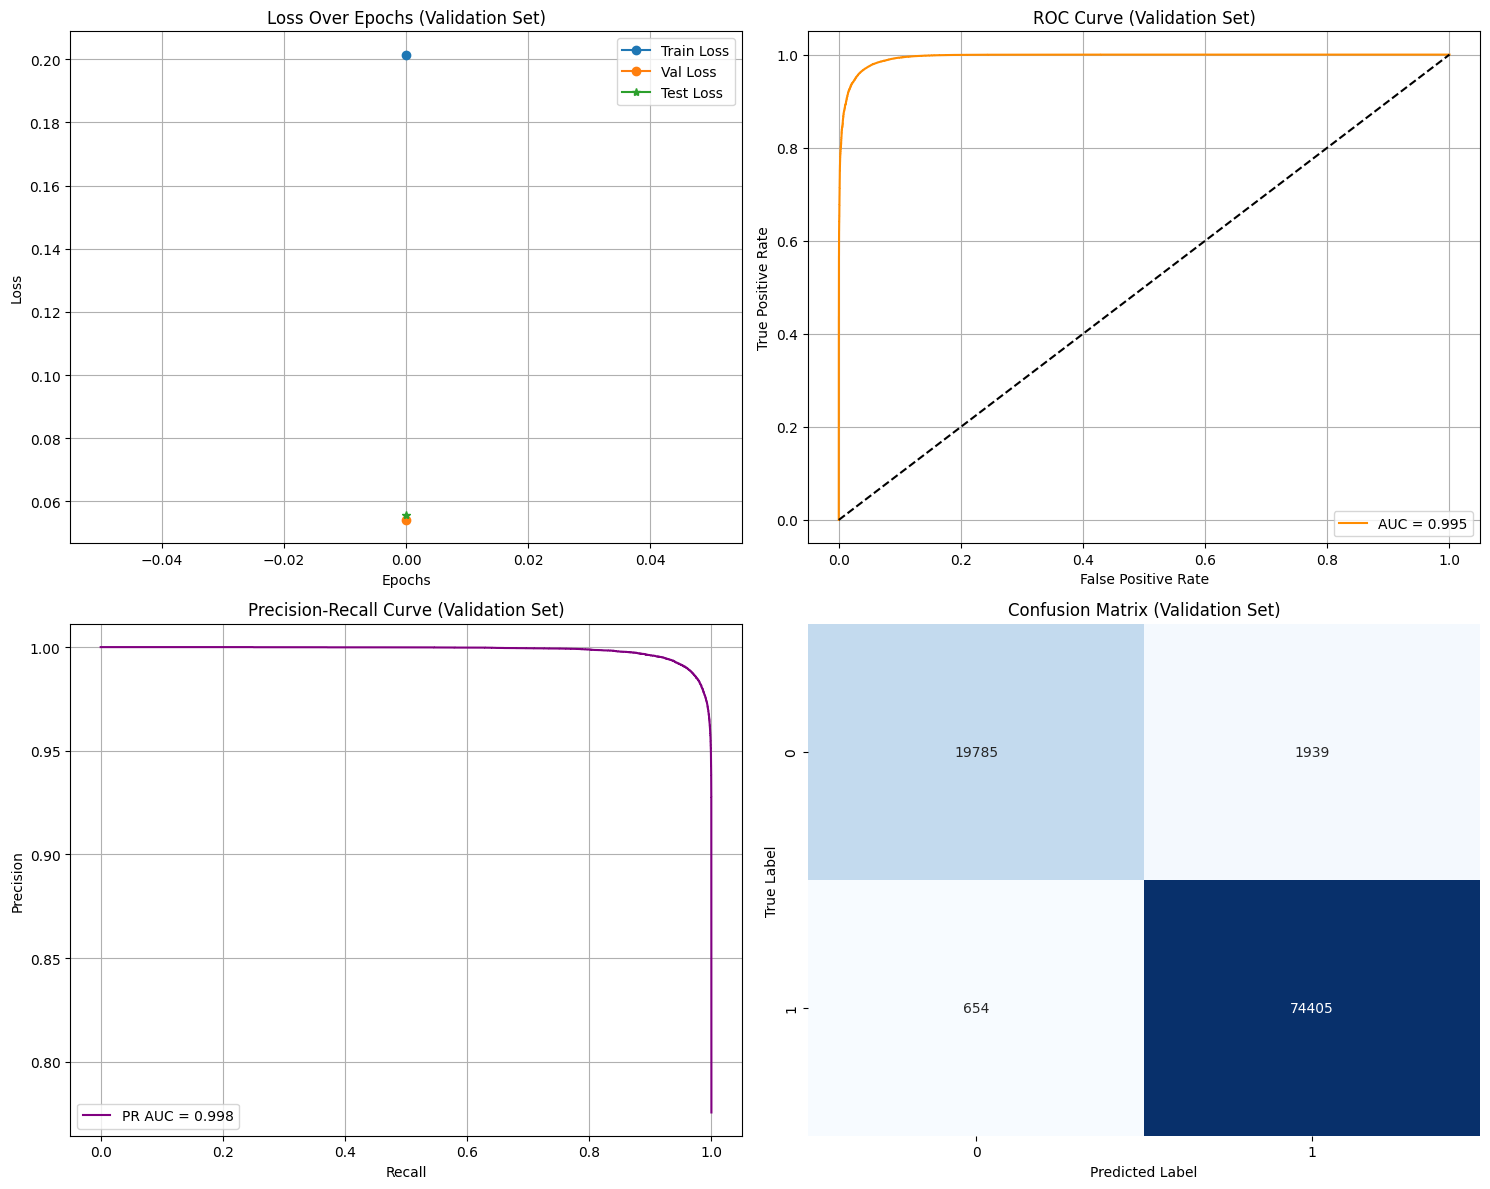


--- Evaluating best model on Test Set ---



FINAL EVALUATION METRICS (Test Set)
AUC-ROC:   0.9948
PR-AUC:    0.9984
mAP:       0.9984
Precision: 0.9739
Recall:    0.9913
F1 Score:  0.9826



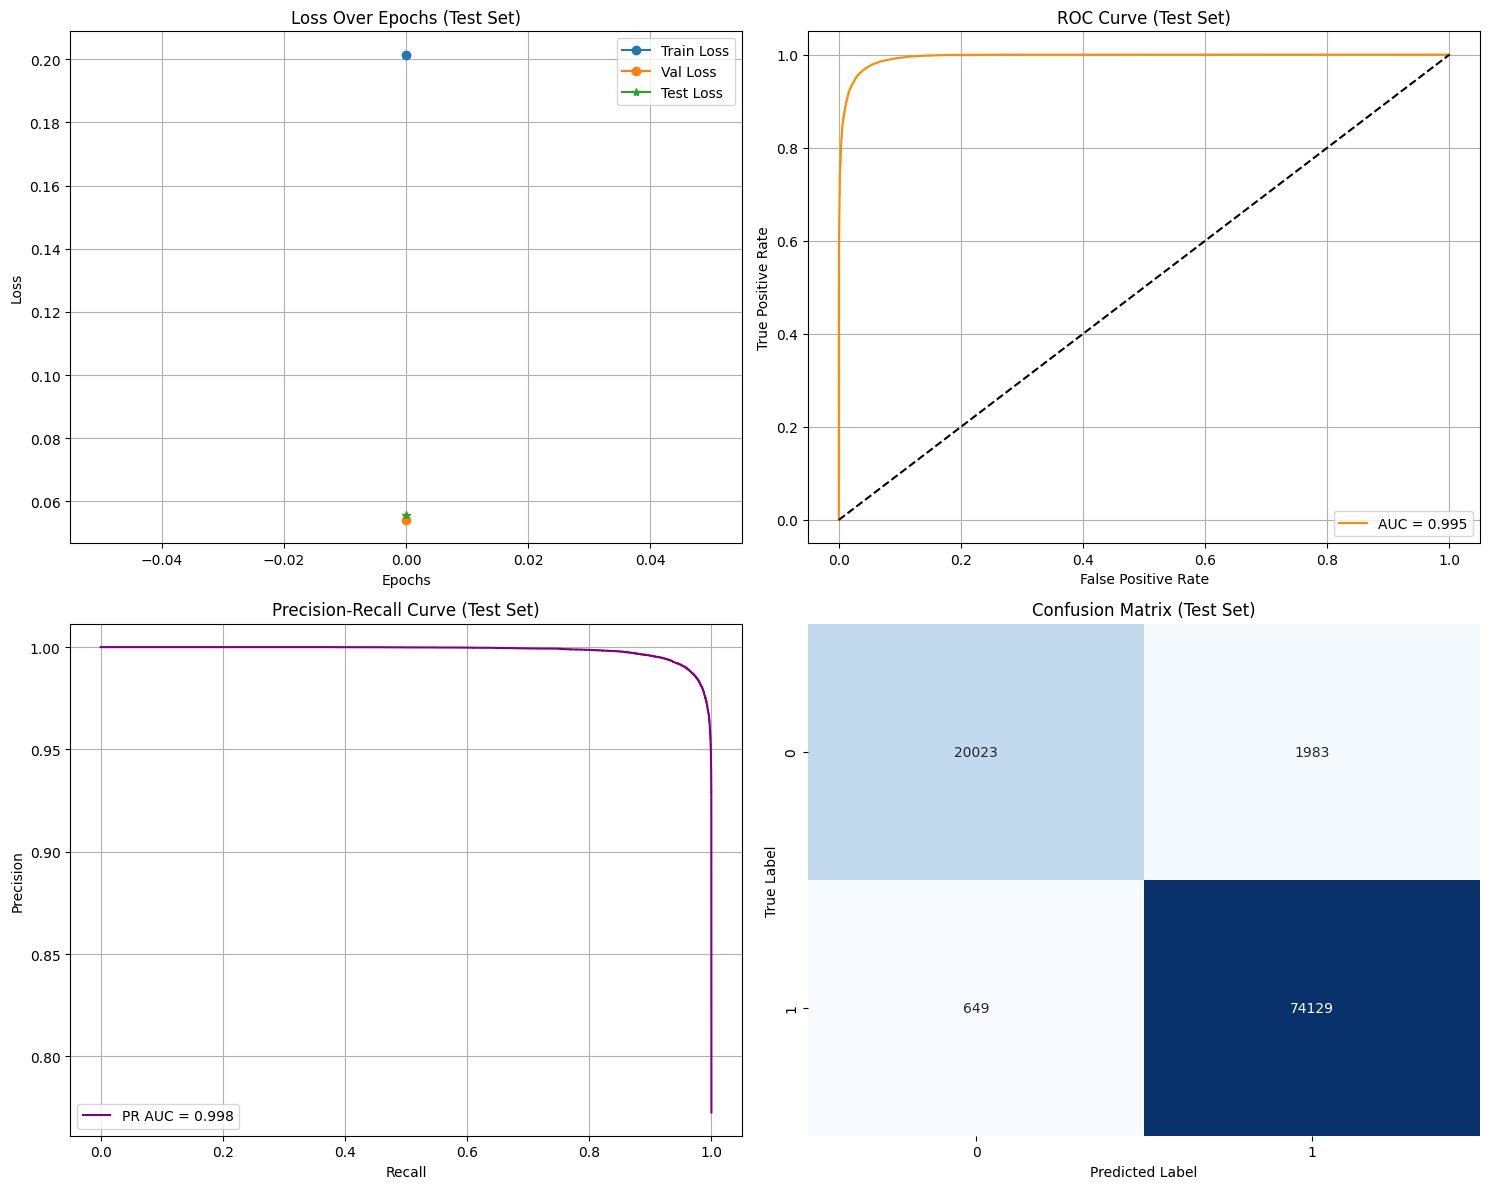

Epoch 2/100 | Train Loss: 0.0509 | Val Loss: 0.0451 | Test Loss: 0.0462
  --> Saved new best model!

--- Validation Metrics (Best Epoch) ---

FINAL EVALUATION METRICS (Validation Set)
AUC-ROC:   0.9964
PR-AUC:    0.9989
mAP:       0.9989
Precision: 0.9778
Recall:    0.9921
F1 Score:  0.9849



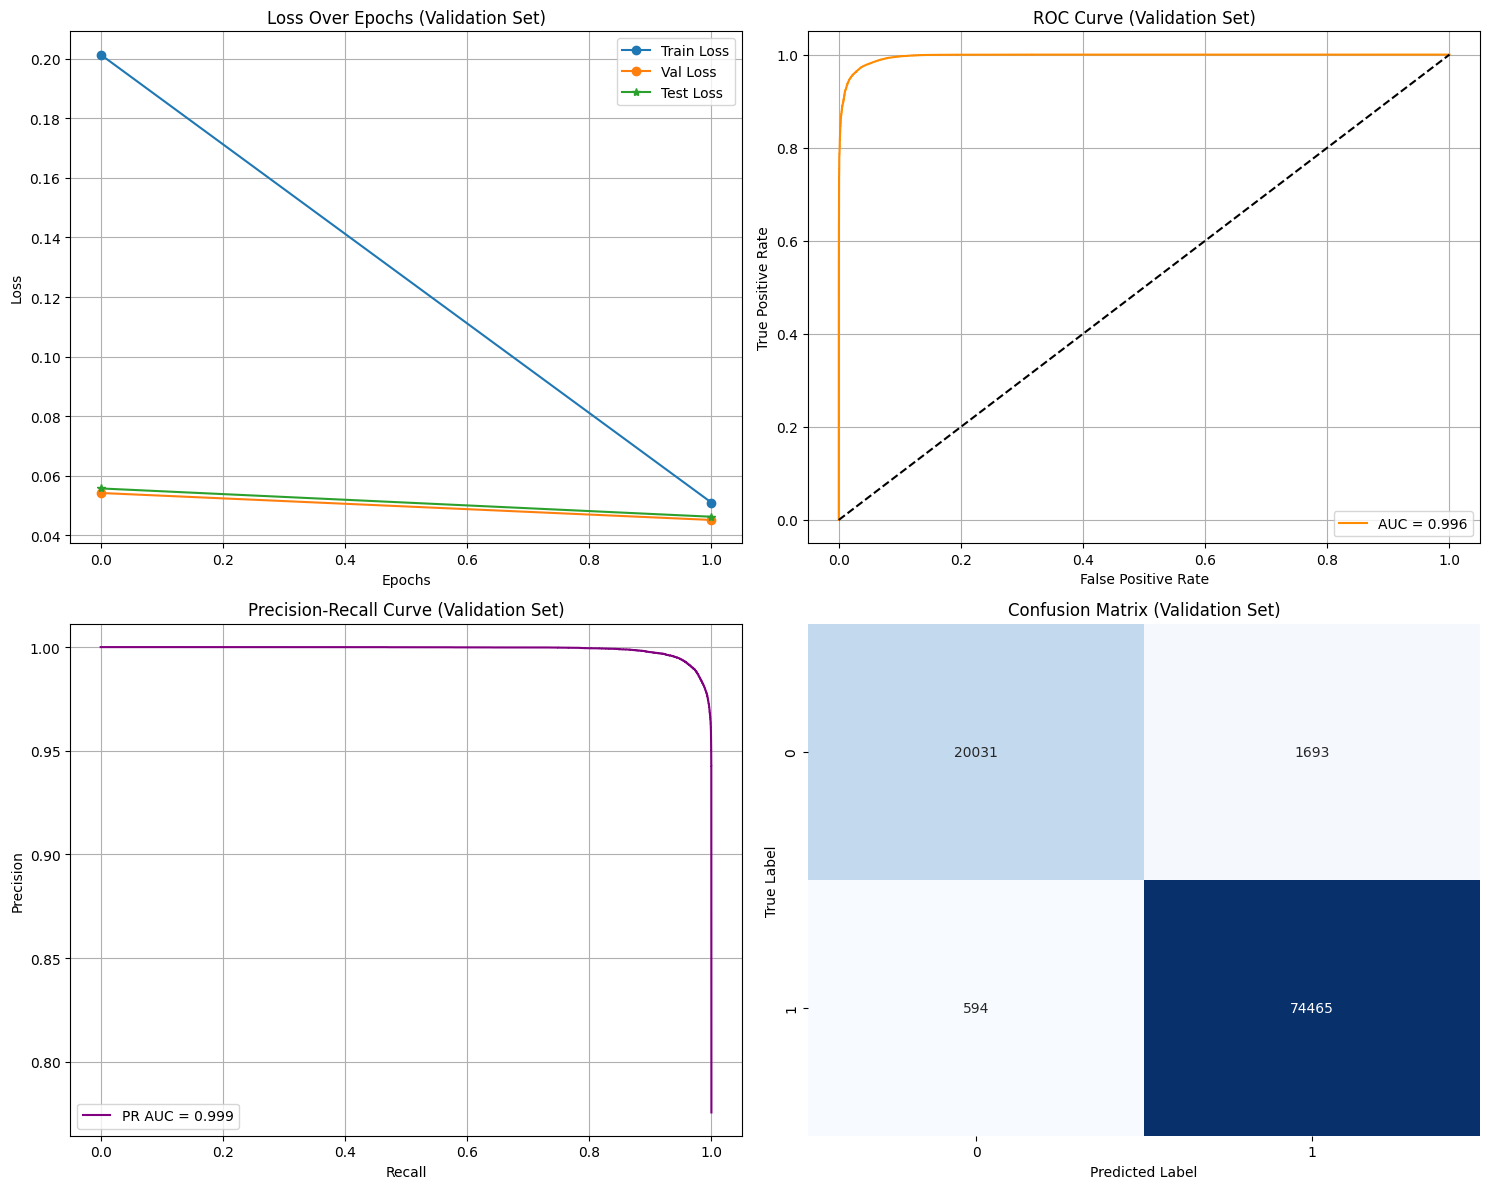


--- Evaluating best model on Test Set ---



FINAL EVALUATION METRICS (Test Set)
AUC-ROC:   0.9964
PR-AUC:    0.9989
mAP:       0.9989
Precision: 0.9767
Recall:    0.9923
F1 Score:  0.9844



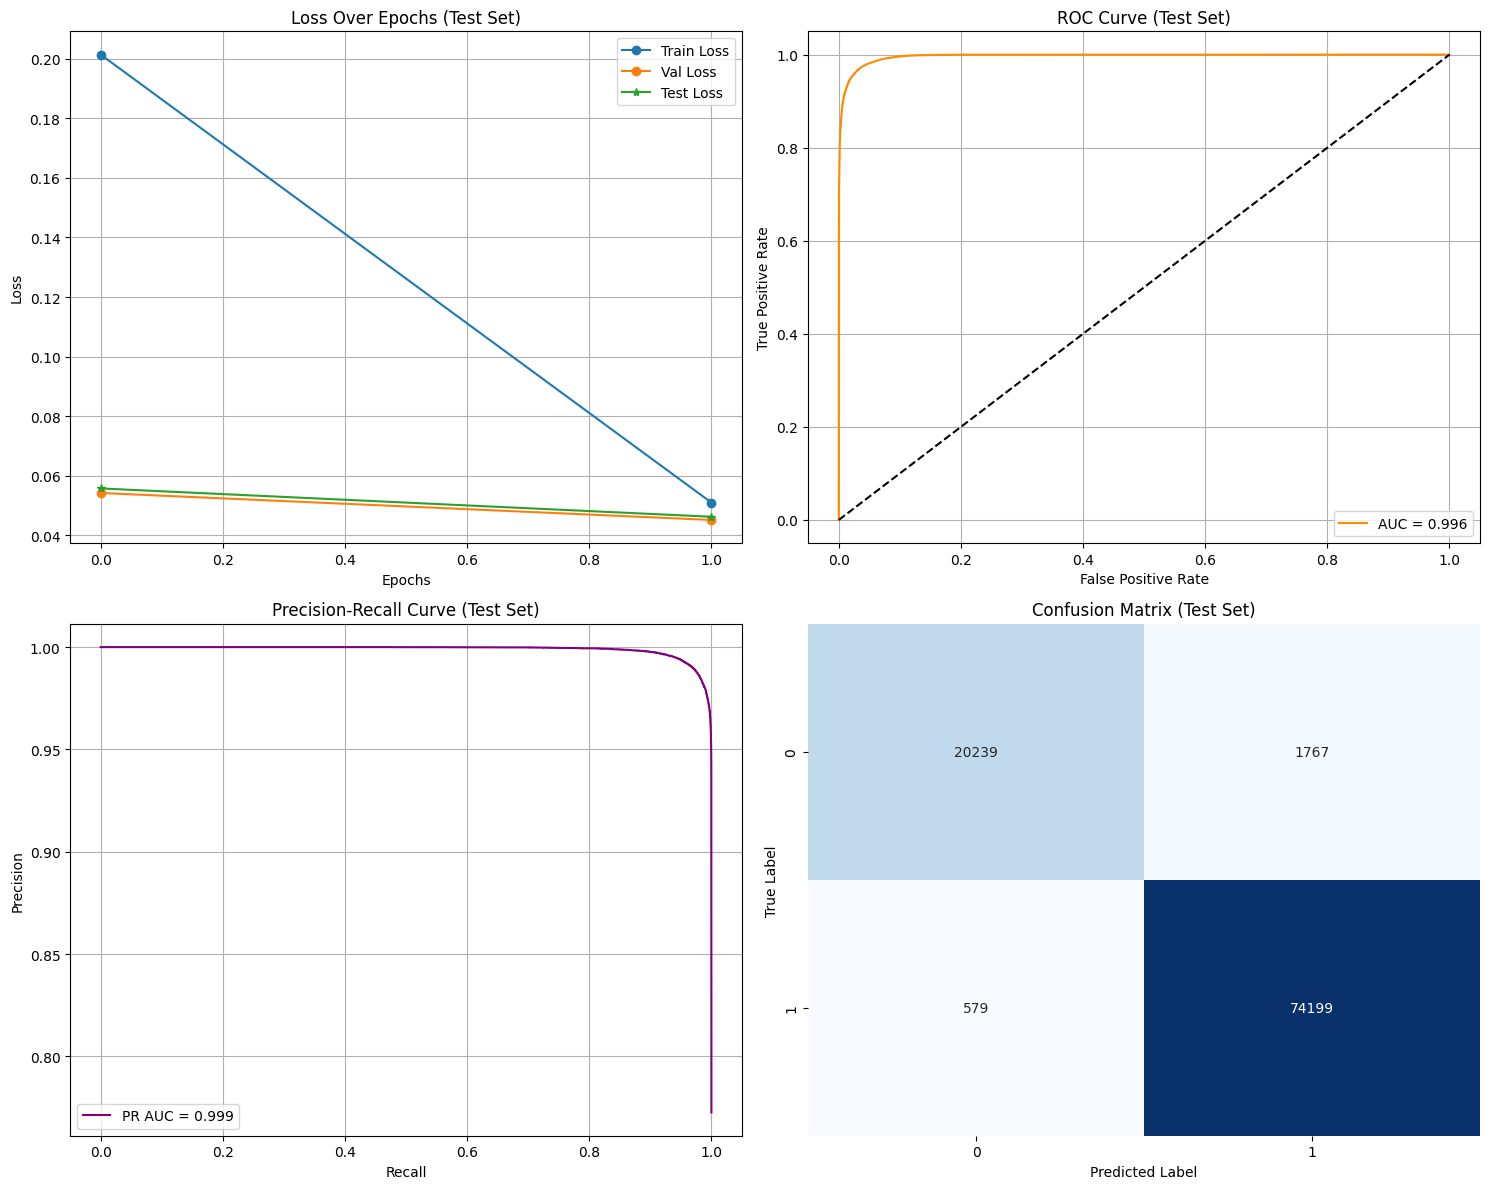

Epoch 3/100 | Train Loss: 0.0373 | Val Loss: 0.0338 | Test Loss: 0.0335
  --> Saved new best model!

--- Validation Metrics (Best Epoch) ---

FINAL EVALUATION METRICS (Validation Set)
AUC-ROC:   0.9971
PR-AUC:    0.9991
mAP:       0.9991
Precision: 0.9937
Recall:    0.9610
F1 Score:  0.9771



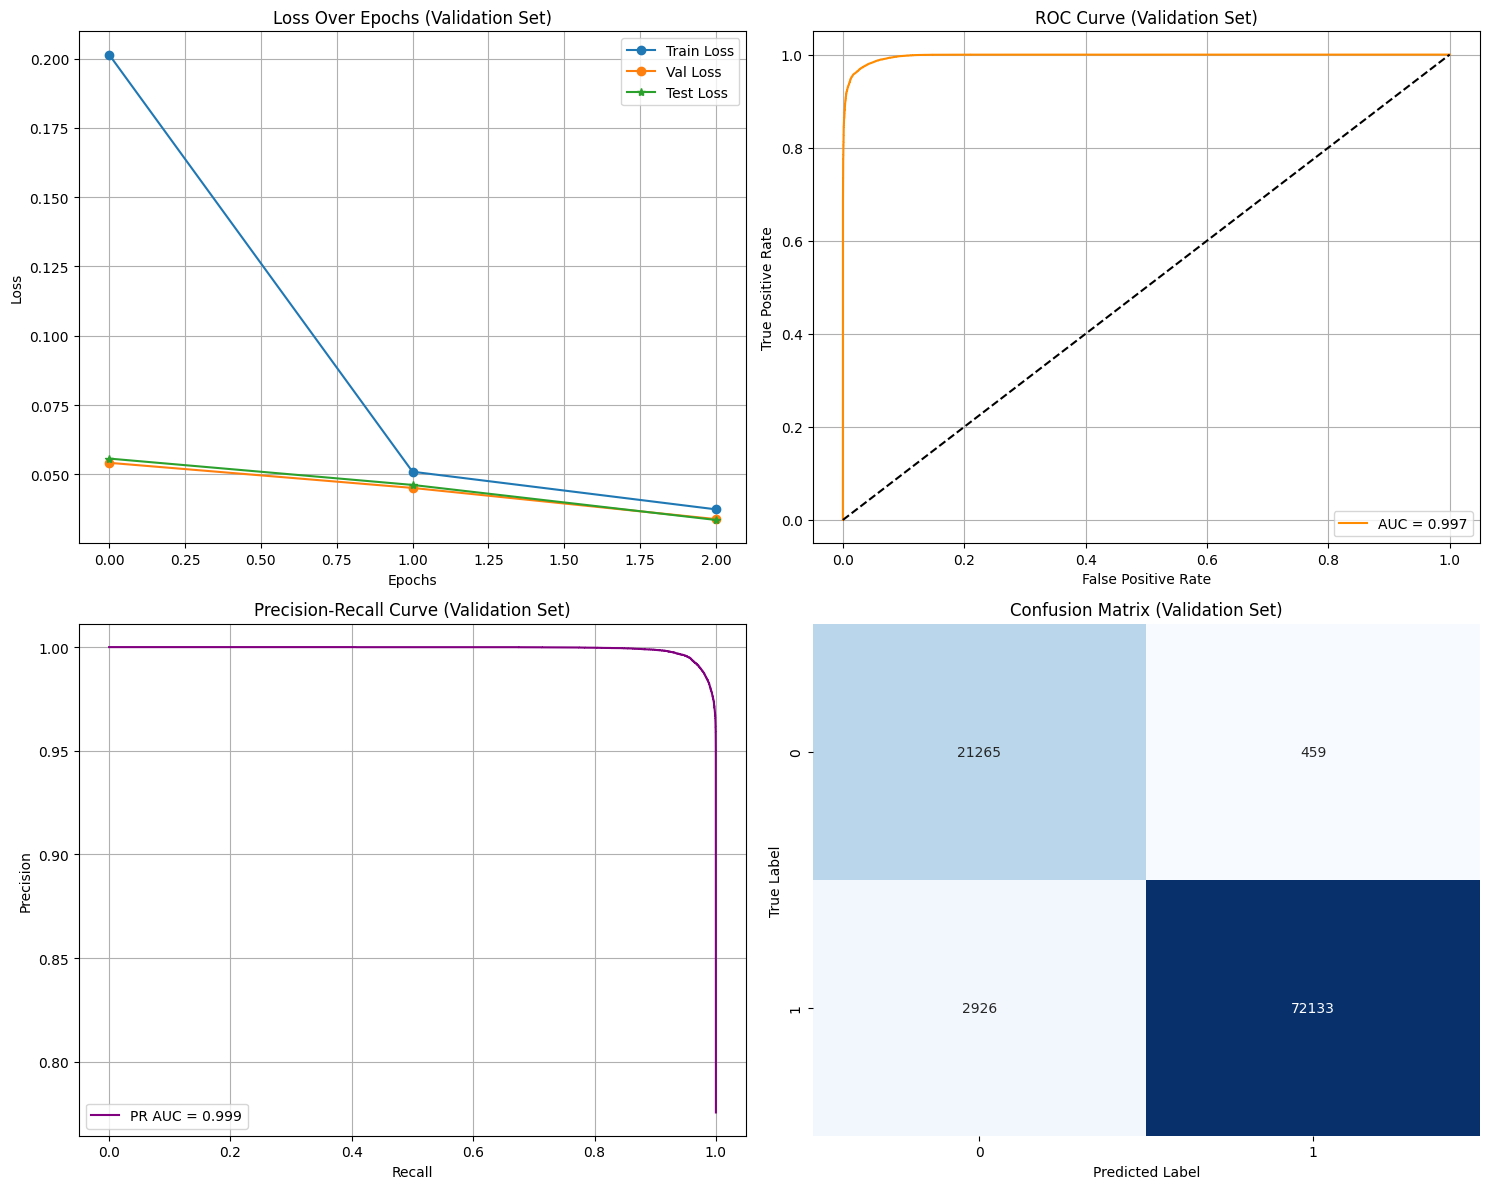


--- Evaluating best model on Test Set ---



FINAL EVALUATION METRICS (Test Set)
AUC-ROC:   0.9971
PR-AUC:    0.9991
mAP:       0.9991
Precision: 0.9934
Recall:    0.9622
F1 Score:  0.9775



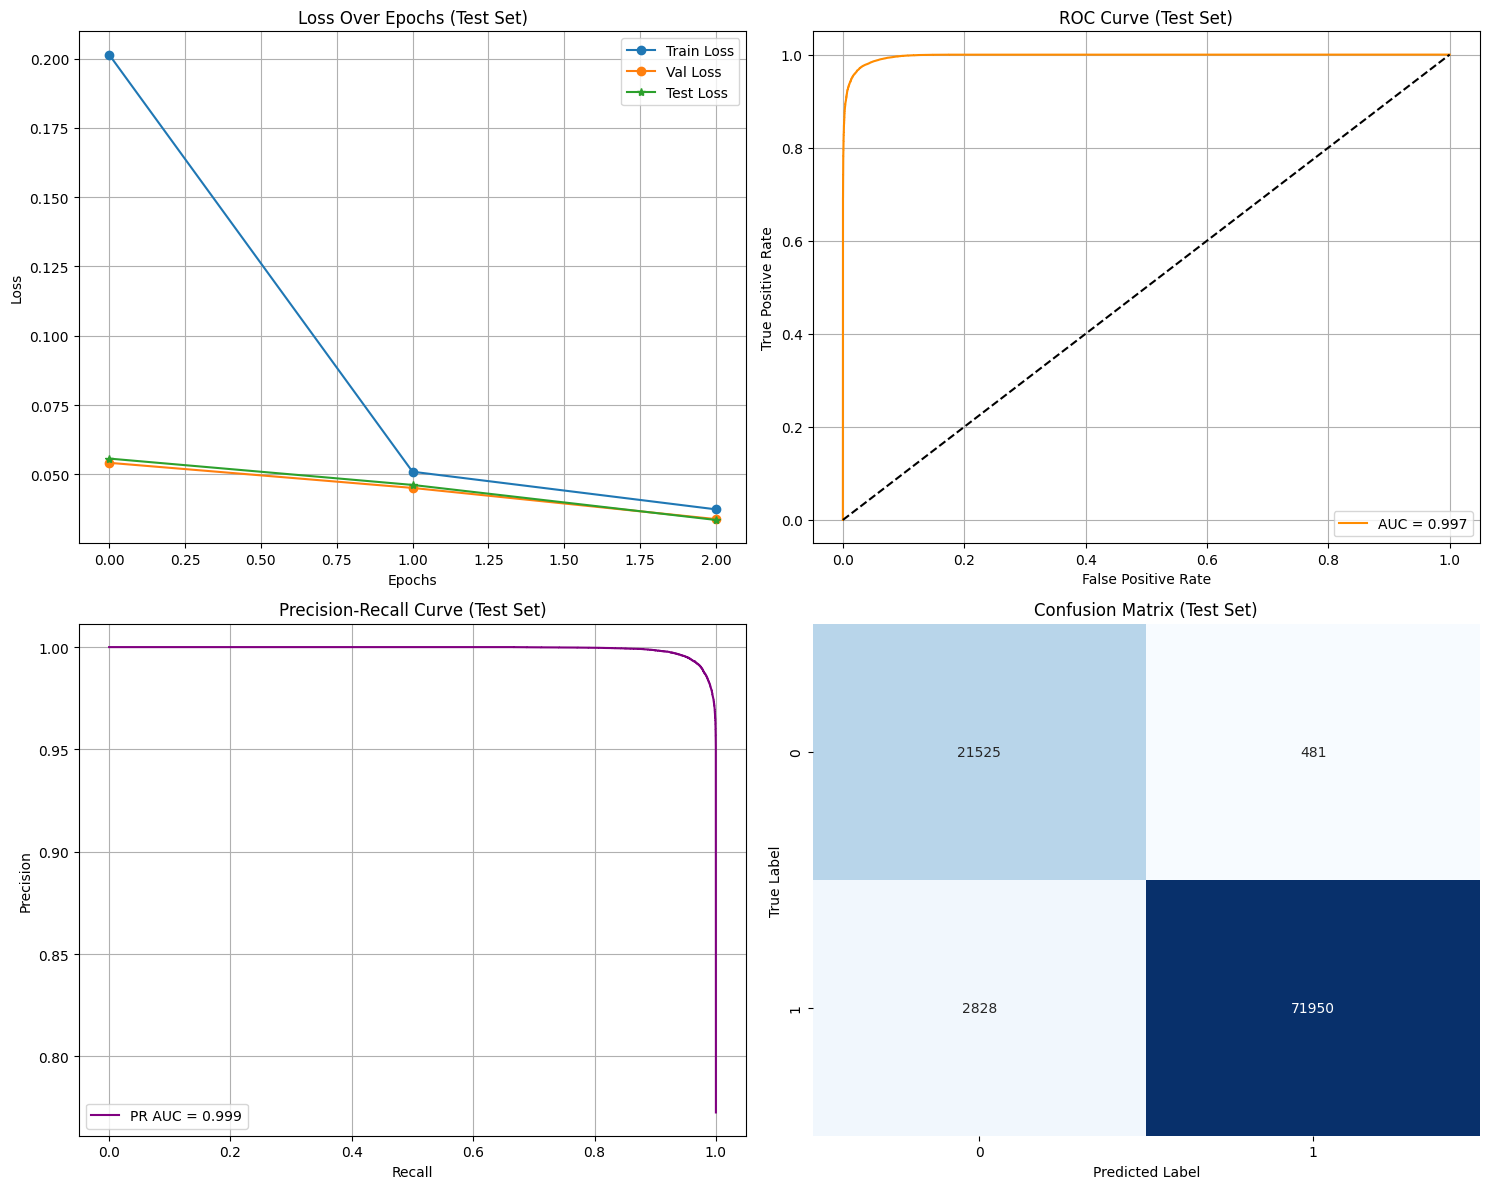

KeyboardInterrupt: 

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# 1. Load your single CSV
print("Loading CSV...")
df = pd.read_csv("csvs/processed/all_beauty.csv")

df['npy_index'] = range(len(df))
# 2. Split the data (70% for training, 15% validation, 15% testing)
# This shuffles the entire dataset once before splitting
print("Splitting data...")
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, shuffle=True)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

# 3. Define Constants
BATCH = 128
D_MODEL = 512
DENSE_EMBEDDINGS_PATH = "csvs/processed/all_beauty.npy"
EPOCHS = 100
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 4. Instantiate Datasets
train_dataset = RecDataset(train_df, DENSE_EMBEDDINGS_PATH)
val_dataset = RecDataset(val_df, DENSE_EMBEDDINGS_PATH)
test_dataset = RecDataset(test_df, DENSE_EMBEDDINGS_PATH)

# 5. Create DataLoaders optimized for GPU transfer
# - shuffle=True: Shuffles the indices every epoch
# - pin_memory=True: Speeds up the transfer from CPU RAM to GPU VRAM
# - num_workers=4: Uses 4 CPU cores to prepare batches in parallel
# - prefetch_factor=2: Queues up 2 batches per worker in advance
print("Creating DataLoaders...")
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH, 
    shuffle=True, 
    num_workers=4,       # Adjust based on your CPU cores (usually 4 to 8 is good)
    pin_memory=True,     # CRITICAL for fast GPU transfer
    prefetch_factor=2,
    persistent_workers=True,
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH, 
    shuffle=False,       # No need to shuffle validation data
    num_workers=4, 
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True,
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH, 
    shuffle=False,       # No need to shuffle test data
    num_workers=4, 
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True,
)

# 6. Initialize your model
print("Initializing model...")
model = xDeepFM(
    device=DEVICE, 
    d_model=D_MODEL, 
    d_clip=1024,          # Ensure this matches the output dimension of Jina CLIP
    num_users=df['userId'].max() + 1,     # Automatically set embedding sizes based on max ID
    num_tweets=df['tweetId'].max() + 1, 
    num_authors=df['authorId'].max() + 1
).to(DEVICE)

# 7. Start the loop
best_model = train_and_test(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    test_loader=test_loader, 
    device=DEVICE, 
    epochs=EPOCHS, 
    patience=15
)